In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/emi_prediction_dataset.csv", low_memory=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [3]:
age_numeric = pd.to_numeric(df['age'], errors='coerce')
print(age_numeric.isna().sum())

3


In [4]:
bad_ages = df[age_numeric.isna()]
print(bad_ages[['age']])

           age
109660  58.0.0
238011  38.0.0
315969  32.0.0


In [5]:
df.isnull().sum().sort_values(ascending=False)

monthly_rent              2426
bank_balance              2426
credit_score              2420
education                 2404
emergency_fund            2351
marital_status               0
monthly_salary               0
years_of_employment          0
gender                       0
employment_type              0
age                          0
family_size                  0
house_type                   0
company_type                 0
dependents                   0
groceries_utilities          0
school_fees                  0
college_fees                 0
travel_expenses              0
current_emi_amount           0
existing_loans               0
other_monthly_expenses       0
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print(df['emi_eligibility'].value_counts())
print(df['emi_eligibility'].value_counts(normalize=True) * 100)

emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64
emi_eligibility
Not_Eligible    77.289526
Eligible        18.390316
High_Risk        4.320158
Name: proportion, dtype: float64


In [8]:
df['max_monthly_emi'].describe()

count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

<Axes: >

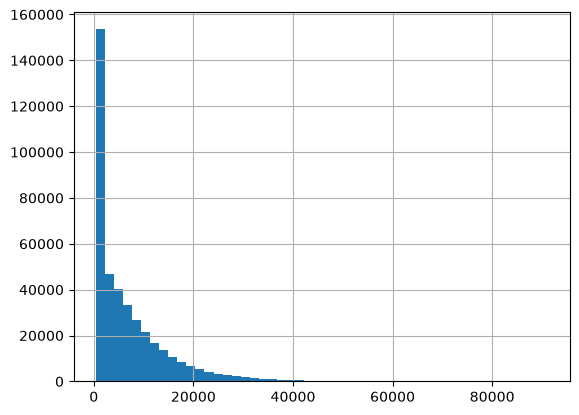

In [9]:
df['max_monthly_emi'].hist(bins=50)

In [10]:
both_missing = df['monthly_rent'].isna() & df['bank_balance'].isna()
print(both_missing.sum())

15


In [11]:
df['age'] = df['age'].astype(str).str.replace(r'(\.\d+)\.\d+$', r'\1', regex=True)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
print(df['age'].isna().sum())

0


In [12]:
for col in ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']:
    df[col] = df[col].fillna(df[col].median())

df['education'] = df['education'].fillna('Unknown')

print(df.isnull().sum().sum())

TypeError: Cannot convert ['303200.0' '92500.0' '672100.0' ... '191600.0' '170400.0' '214400.0'] to numeric

In [ ]:
for col in ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df['education'] = df['education'].fillna('Unknown')

print(df.isnull().sum().sum())

0


In [ ]:
df.to_csv("../data/processed/emi_cleaned.csv", index=False)

In [ ]:
df['debt_to_income_ratio'] = (df['current_emi_amount'] + df['monthly_rent']) / df['monthly_salary']

df['loan_to_income_ratio'] = df['requested_amount'] / (df['monthly_salary'] * 12)

df['disposable_income'] = df['monthly_salary'] - (
    df['monthly_rent'] + df['school_fees'] + df['college_fees'] +
    df['travel_expenses'] + df['groceries_utilities'] +
    df['other_monthly_expenses'] + df['current_emi_amount']
)

df['savings_rate'] = df['bank_balance'] / df['monthly_salary']

df['dependents_ratio'] = df['dependents'] / df['family_size']

print(df[['debt_to_income_ratio', 'loan_to_income_ratio', 'disposable_income', 'savings_rate', 'dependents_ratio']].describe())

TypeError: unsupported operand type(s) for /: 'float' and 'str'

In [ ]:
df.dtypes

age                       float64
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance               object
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object

In [ ]:
print(df['monthly_salary'].dtype)
print(df['monthly_salary'].head())

object
0    82600.0
1    21500.0
2    86100.0
3    66800.0
4    57300.0
Name: monthly_salary, dtype: object


In [ ]:
df['monthly_salary'] = pd.to_numeric(df['monthly_salary'], errors='coerce')
print(df['monthly_salary'].isna().sum())

1993


In [ ]:
df.select_dtypes(include='object').columns.tolist()

['gender',
 'marital_status',
 'education',
 'employment_type',
 'company_type',
 'house_type',
 'existing_loans',
 'bank_balance',
 'emi_scenario',
 'emi_eligibility']

In [ ]:
bad_salaries = df[pd.to_numeric(df['monthly_salary'], errors='coerce').isna()]
print(bad_salaries['monthly_salary'].head(10))

844    NaN
1025   NaN
1244   NaN
1252   NaN
1384   NaN
2026   NaN
2464   NaN
2590   NaN
2725   NaN
2876   NaN
Name: monthly_salary, dtype: float64


In [ ]:
df = pd.read_csv("../data/processed/emi_cleaned.csv", low_memory=False)
df.dtypes

age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses           float64
groceries_utilities       float64
other_monthly_expenses    float64
existing_loans             object
current_emi_amount        float64
credit_score              float64
bank_balance              float64
emergency_fund            float64
emi_scenario               object
requested_amount          float64
requested_tenure            int64
emi_eligibility            object
max_monthly_emi           float64
dtype: object

In [ ]:
df['monthly_salary'] = pd.to_numeric(df['monthly_salary'], errors='coerce')
print("monthly_salary NaNs after coerce:", df['monthly_salary'].isna().sum())

df['monthly_salary'] = df['monthly_salary'].fillna(df['monthly_salary'].median())
print("Total nulls remaining in dataset:", df.isnull().sum().sum())

monthly_salary NaNs after coerce: 1993
Total nulls remaining in dataset: 0


In [ ]:
df['debt_to_income_ratio'] = (df['current_emi_amount'] + df['monthly_rent']) / df['monthly_salary']
df['loan_to_income_ratio'] = df['requested_amount'] / (df['monthly_salary'] * 12)
df['disposable_income'] = df['monthly_salary'] - (
    df['monthly_rent'] + df['school_fees'] + df['college_fees'] +
    df['travel_expenses'] + df['groceries_utilities'] +
    df['other_monthly_expenses'] + df['current_emi_amount']
)
df['savings_rate'] = df['bank_balance'] / df['monthly_salary']
df['dependents_ratio'] = df['dependents'] / df['family_size']

print(df[['debt_to_income_ratio', 'loan_to_income_ratio', 'disposable_income', 'savings_rate', 'dependents_ratio']].describe())

       debt_to_income_ratio  loan_to_income_ratio  disposable_income  \
count         404800.000000         404800.000000      404800.000000   
mean               0.191322              0.725626       14831.331744   
std                0.245613              0.960184       37581.517747   
min                0.000000              0.001893     -161883.000000   
25%                0.000000              0.182455         400.000000   
50%                0.183817              0.398804       10600.000000   
75%                0.288660              0.902617       22400.000000   
max               16.297906             24.546407      485540.000000   

        savings_rate  dependents_ratio  
count  404800.000000     404800.000000  
mean        4.448338          0.590829  
std         3.959213          0.215541  
min         0.020562          0.000000  
25%         2.345000          0.500000  
50%         4.235848          0.666667  
75%         6.143676          0.750000  
max       218.462139   

In [ ]:
df.to_csv("../data/processed/emi_features.csv", index=False)

In [ ]:
from sklearn.model_selection import train_test_split

# Drop both targets from features — X should never see the answer
X = df.drop(columns=['emi_eligibility', 'max_monthly_emi'])
y_class = df['emi_eligibility']
y_reg = df['max_monthly_emi']

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

print("Feature count after encoding:", X.shape[1])

# Stratified split for classification
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(y_class_train.value_counts(normalize=True))
print(y_class_test.value_counts(normalize=True))

Feature count after encoding: 76
Train shape: (323840, 76)
Test shape: (80960, 76)
emi_eligibility
Not_Eligible    0.772894
Eligible        0.183903
High_Risk       0.043203
Name: proportion, dtype: float64
emi_eligibility
Not_Eligible    0.772900
Eligible        0.183906
High_Risk       0.043194
Name: proportion, dtype: float64


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

mlflow.set_experiment("emi_classification")

with mlflow.start_run(run_name="logistic_regression_baseline"):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_class_train)
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_class_test, preds)
    
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(model, "model")
    
    print("Accuracy:", acc)
    print(classification_report(y_class_test, preds))

2026/08/17 13:44:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/17 13:44:21 INFO mlflow.store.db.utils: Updating database tables
2026/08/17 13:44:24 INFO mlflow.tracking.fluent: Experiment with name 'emi_classification' does not exist. Creating a new experiment.
d:\emipredict-ai\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/08/17 13:45:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.85800395256917
              precision    recall  f1-score   support

    Eligible       0.71      0.66      0.69     14889
   High_Risk       0.14      0.00      0.00      3497
Not_Eligible       0.89      0.95      0.92     62574

    accuracy                           0.86     80960
   macro avg       0.58      0.54      0.54     80960
weighted avg       0.82      0.86      0.84     80960



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

with mlflow.start_run(run_name="logistic_regression_balanced"):
    model2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    model2.fit(X_train_scaled, y_class_train)
    
    preds2 = model2.predict(X_test_scaled)
    acc2 = accuracy_score(y_class_test, preds2)
    
    mlflow.log_metric("accuracy", acc2)
    mlflow.sklearn.log_model(model2, "model")
    
    print("Accuracy:", acc2)
    print(classification_report(y_class_test, preds2))

2026/08/17 13:50:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.794429347826087
              precision    recall  f1-score   support

    Eligible       0.84      0.76      0.80     14889
   High_Risk       0.15      0.68      0.24      3497
Not_Eligible       0.99      0.81      0.89     62574

    accuracy                           0.79     80960
   macro avg       0.66      0.75      0.64     80960
weighted avg       0.92      0.79      0.84     80960



In [ ]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="random_forest_baseline"):
    rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_class_train)  # unscaled — trees don't need it
    
    rf_preds = rf_model.predict(X_test)
    rf_acc = accuracy_score(y_class_test, rf_preds)
    
    mlflow.log_metric("accuracy", rf_acc)
    mlflow.sklearn.log_model(rf_model, "model")
    
    print("Accuracy:", rf_acc)
    print(classification_report(y_class_test, rf_preds))

2026/08/17 13:55:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.9316082015810276
              precision    recall  f1-score   support

    Eligible       0.80      0.97      0.87     14889
   High_Risk       0.50      0.09      0.16      3497
Not_Eligible       0.97      0.97      0.97     62574

    accuracy                           0.93     80960
   macro avg       0.76      0.68      0.67     80960
weighted avg       0.92      0.93      0.92     80960



In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_class_train)

with mlflow.start_run(run_name="xgboost_baseline"):
    xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
    xgb_model.fit(X_train, y_class_train, sample_weight=sample_weights)
    
    xgb_preds = xgb_model.predict(X_test)
    xgb_acc = accuracy_score(y_class_test, xgb_preds)
    
    mlflow.log_metric("accuracy", xgb_acc)
    mlflow.sklearn.log_model(xgb_model, "model")
    
    print("Accuracy:", xgb_acc)
    print(classification_report(y_class_test, xgb_preds))

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['Eligible' 'High_Risk' 'Not_Eligible']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_class_train_encoded = le.fit_transform(y_class_train)
y_class_test_encoded = le.transform(y_class_test)

with mlflow.start_run(run_name="xgboost_baseline"):
    xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
    xgb_model.fit(X_train, y_class_train_encoded, sample_weight=sample_weights)
    
    xgb_preds = xgb_model.predict(X_test)
    xgb_acc = accuracy_score(y_class_test_encoded, xgb_preds)
    
    mlflow.log_metric("accuracy", xgb_acc)
    mlflow.sklearn.log_model(xgb_model, "model")
    
    print("Accuracy:", xgb_acc)
    print(classification_report(y_class_test_encoded, xgb_preds, target_names=le.classes_))

2026/08/17 14:04:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['xgboost.core.Booster', 'xgboost.sklearn.XGBClassifier'].

In [ ]:
import mlflow.xgboost

with mlflow.start_run(run_name="xgboost_baseline"):
    xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
    xgb_model.fit(X_train, y_class_train_encoded, sample_weight=sample_weights)
    
    xgb_preds = xgb_model.predict(X_test)
    xgb_acc = accuracy_score(y_class_test_encoded, xgb_preds)
    
    mlflow.log_metric("accuracy", xgb_acc)
    mlflow.xgboost.log_model(xgb_model, "model")
    
    print("Accuracy:", xgb_acc)
    print(classification_report(y_class_test_encoded, xgb_preds, target_names=le.classes_))

2026/08/17 14:06:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.92987895256917
              precision    recall  f1-score   support

    Eligible       0.98      0.90      0.94     14889
   High_Risk       0.38      0.94      0.54      3497
Not_Eligible       1.00      0.94      0.97     62574

    accuracy                           0.93     80960
   macro avg       0.79      0.93      0.82     80960
weighted avg       0.97      0.93      0.94     80960



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

mlflow.set_experiment("emi_regression")

def evaluate_and_log(model, name, X_tr, X_te, y_tr, y_te, xgb=False):
    with mlflow.start_run(run_name=name):
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        rmse = np.sqrt(mean_squared_error(y_te, preds))
        mae = mean_absolute_error(y_te, preds)
        r2 = r2_score(y_te, preds)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        if xgb:
            mlflow.xgboost.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")
        print(f"{name} — RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")
        return model

lr_model = evaluate_and_log(LinearRegression(), "linear_regression_baseline", X_train_r, X_test_r, y_reg_train, y_reg_test)

rf_reg_model = evaluate_and_log(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), "random_forest_regressor", X_train_r, X_test_r, y_reg_train, y_reg_test)

xgb_reg_model = evaluate_and_log(XGBRegressor(n_estimators=100, random_state=42), "xgboost_regressor", X_train_r, X_test_r, y_reg_train, y_reg_test, xgb=True)

NameError: name 'X' is not defined

In [ ]:
print('df exists:', 'df' in dir())
print('X exists:', 'X' in dir())
print('y_reg exists:', 'y_reg' in dir())
print('y_class exists:', 'y_class' in dir())

df exists: True
X exists: False
y_reg exists: False
y_class exists: False


In [ ]:
import pandas as pd
import numpy as np

# Reload raw data fresh
df = pd.read_csv("../data/raw/emi_prediction_dataset.csv", low_memory=False)

# --- Day 3: cleaning ---
df['age'] = df['age'].astype(str).str.replace(r'(\.\d+)\.\d+$', r'\1', regex=True)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

for col in ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund', 'monthly_salary']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df['education'] = df['education'].fillna('Unknown')
df['age'] = df['age'].fillna(df['age'].median())

# --- Day 4: feature engineering ---
df['debt_to_income_ratio'] = (df['current_emi_amount'] + df['monthly_rent']) / df['monthly_salary']
df['loan_to_income_ratio'] = df['requested_amount'] / (df['monthly_salary'] * 12)
df['disposable_income'] = df['monthly_salary'] - (
    df['monthly_rent'] + df['school_fees'] + df['college_fees'] +
    df['travel_expenses'] + df['groceries_utilities'] +
    df['other_monthly_expenses'] + df['current_emi_amount']
)
df['savings_rate'] = df['bank_balance'] / df['monthly_salary']
df['dependents_ratio'] = df['dependents'] / df['family_size']

# --- Day 5: build X and y ---
X = df.drop(columns=['emi_eligibility', 'max_monthly_emi'])
y_class = df['emi_eligibility']
y_reg = df['max_monthly_emi']
X = pd.get_dummies(X, drop_first=True)

print("Nulls remaining:", df.isnull().sum().sum())
print("X shape:", X.shape)
print("y_class exists:", 'y_class' in dir())
print("y_reg exists:", 'y_reg' in dir())

Nulls remaining: 0
X shape: (404800, 47)
y_class exists: True
y_reg exists: True


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import mlflow
import mlflow.sklearn
import mlflow.xgboost

X_train_r, X_test_r, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

mlflow.set_experiment("emi_regression")

def evaluate_and_log(model, name, X_tr, X_te, y_tr, y_te, xgb=False):
    with mlflow.start_run(run_name=name):
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        rmse = np.sqrt(mean_squared_error(y_te, preds))
        mae = mean_absolute_error(y_te, preds)
        r2 = r2_score(y_te, preds)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        if xgb:
            mlflow.xgboost.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")
        print(f"{name} — RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")
        return model

lr_model = evaluate_and_log(LinearRegression(), "linear_regression_baseline", X_train_r, X_test_r, y_reg_train, y_reg_test)

rf_reg_model = evaluate_and_log(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), "random_forest_regressor", X_train_r, X_test_r, y_reg_train, y_reg_test)

xgb_reg_model = evaluate_and_log(XGBRegressor(n_estimators=100, random_state=42), "xgboost_regressor", X_train_r, X_test_r, y_reg_train, y_reg_test, xgb=True)

2026/08/20 13:14:02 INFO mlflow.tracking.fluent: Experiment with name 'emi_regression' does not exist. Creating a new experiment.
2026/08/20 13:14:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


linear_regression_baseline — RMSE: 4178.05, MAE: 3000.31, R2: 0.7043


2026/08/20 13:15:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


random_forest_regressor — RMSE: 934.34, MAE: 210.27, R2: 0.9852


2026/08/20 13:16:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


xgboost_regressor — RMSE: 709.68, MAE: 247.77, R2: 0.9915


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os

# Rebuild classification split
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

le = LabelEncoder()
y_class_train_encoded = le.fit_transform(y_class_train)
y_class_test_encoded = le.transform(y_class_test)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_class_train)

xgb_clf_final = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_clf_final.fit(X_train, y_class_train_encoded, sample_weight=sample_weights)

preds = xgb_clf_final.predict(X_test)
print("Classifier accuracy:", accuracy_score(y_class_test_encoded, preds))
print(classification_report(y_class_test_encoded, preds, target_names=le.classes_))

# Save everything the app will need
os.makedirs("../models", exist_ok=True)

joblib.dump(xgb_clf_final, "../models/classifier_xgb.pkl")
joblib.dump(xgb_reg_model, "../models/regressor_xgb.pkl")
joblib.dump(le, "../models/label_encoder.pkl")
joblib.dump(list(X.columns), "../models/feature_columns.pkl")

print("All artifacts saved.")

Classifier accuracy: 0.9304100790513834
              precision    recall  f1-score   support

    Eligible       0.98      0.90      0.94     14889
   High_Risk       0.38      0.93      0.55      3497
Not_Eligible       1.00      0.94      0.97     62574

    accuracy                           0.93     80960
   macro avg       0.79      0.92      0.82     80960
weighted avg       0.97      0.93      0.94     80960

All artifacts saved.


In [ ]:
Get-ChildItem ../models -Recurse | Select-Object Name, @{Name="SizeMB";Expression={[math]::Round($_.Length/1MB,2)}}

SyntaxError: invalid decimal literal (4198625173.py, line 1)

In [13]:
for col in ['gender', 'marital_status', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']:
    print(col, ":", df[col].unique())

gender : ['Female' 'Male' 'female' 'male' 'M' 'MALE' 'F' 'FEMALE']
marital_status : ['Married' 'Single']
employment_type : ['Private' 'Government' 'Self-employed']
company_type : ['Mid-size' 'MNC' 'Startup' 'Large Indian' 'Small']
house_type : ['Rented' 'Family' 'Own']
existing_loans : ['Yes' 'No']
emi_scenario : ['Personal Loan EMI' 'E-commerce Shopping EMI' 'Education EMI'
 'Vehicle EMI' 'Home Appliances EMI']
